### Week 6: Data Visualization Mastery with Seaborn

1. Create box plots to understand data distribution
2. Build correlation heatmaps for numerical data
3. Design professional-looking charts with custom styles
4. Create multiple subplots in a single figure
5. Build interactive charts with hover information
6. Combine multiple charts into a dashboard layout

###  Project:
Create an Interactive Sales Dashboard with multiple chart types showing sales trends, customer segmentation, and product performance

###  Tips & Resources:

- Search YouTube: 'Seaborn data visualization tutorial'
- Focus on telling stories with your visualizations
- Learn color theory basics for effective charts
- Practice creating publication-quality graphics
- Get feedback on your visualizations from non-technical friends


### 1. Create box plots to understand data distribution


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

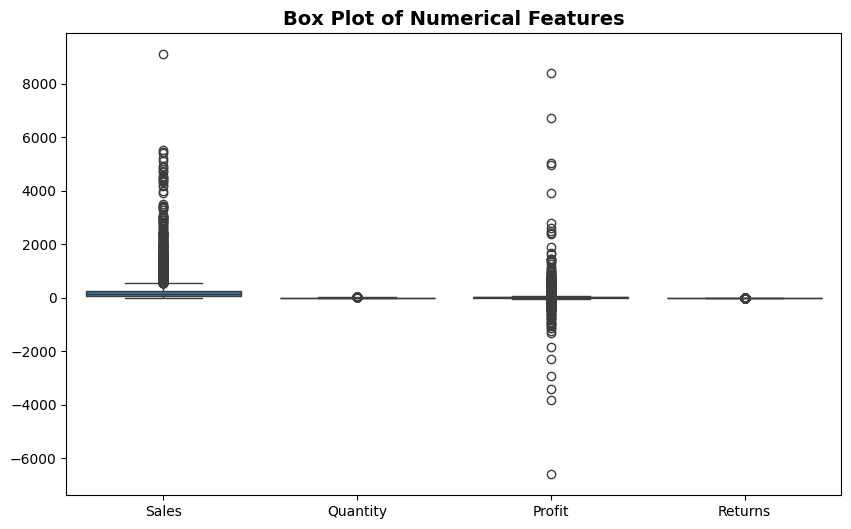

In [2]:
df = pd.read_csv("Amazon Store Sales Data.csv")

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Box plot for numerical columns
numerical_cols = ['Sales', 'Quantity', 'Profit', 'Returns']

plt.figure(figsize=(10,6))
sns.boxplot(data=df[numerical_cols])
plt.title("Box Plot of Numerical Features", fontsize=14, fontweight="bold")
plt.show()


### 2. Build correlation heatmaps for numerical data



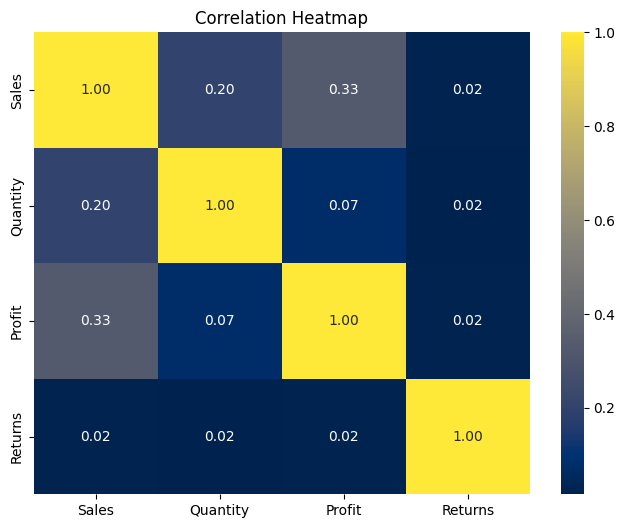

In [3]:
plt.figure(figsize=(8,6))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="cividis", fmt=".2f") #linewidth = 0.5
plt.title("Correlation Heatmap")
plt.show()


### 3. Design professional-looking charts with custom styles


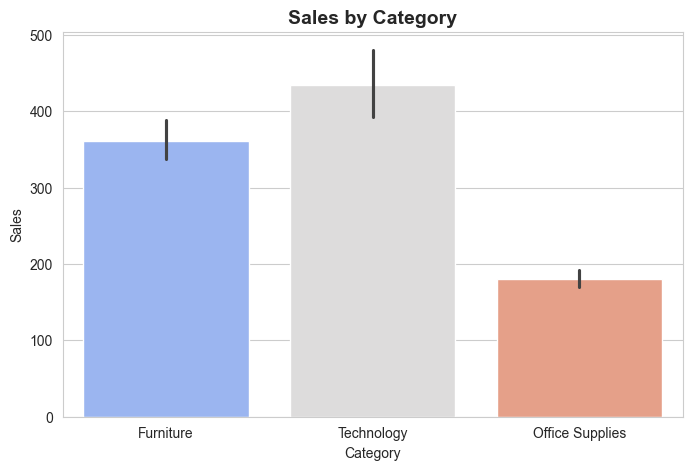

In [4]:
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df, palette="coolwarm")
plt.title("Sales by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()


### 4. Create multiple subplots in a single figure

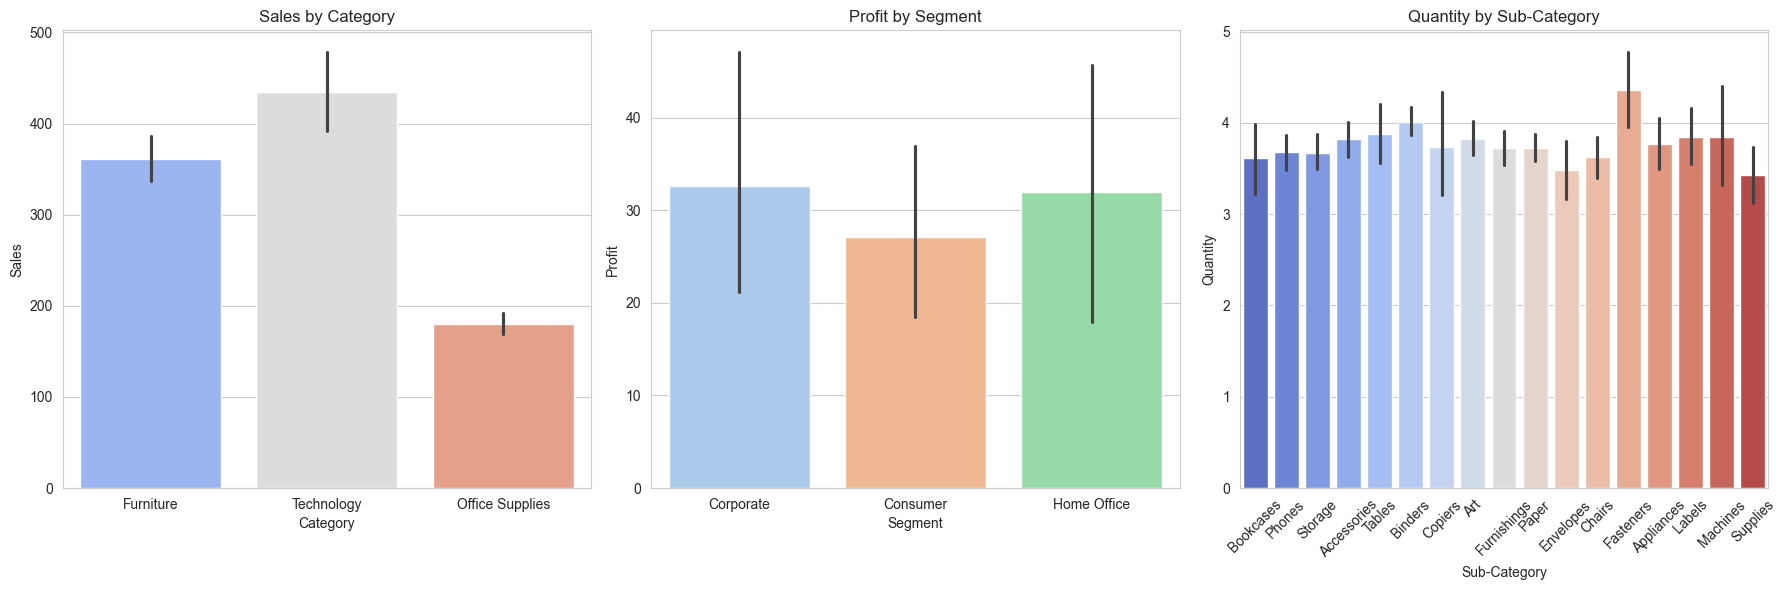

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# 1. Sales by Category
sns.barplot(x='Category', y='Sales', data=df, ax=axes[0], palette="coolwarm")
axes[0].set_title("Sales by Category")

# 2. Profit by Segment
sns.barplot(x='Segment', y='Profit', data=df, ax=axes[1], palette="pastel")
axes[1].set_title("Profit by Segment")

# 3. Quantity by Sub-Category
sns.barplot(x='Sub-Category', y='Quantity', data=df, ax=axes[2], palette="coolwarm")
axes[2].set_title("Quantity by Sub-Category")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 5. Build interactive charts with hover information

In [6]:
import plotly.express as px

# Interactive scatter: Sales vs Profit
fig = px.scatter(df, x="Sales", y="Profit",
                 color="Category",
                 hover_data=["Customer Name", "Product Name"],
                 title="Interactive Sales vs Profit")
fig.show()


### 6. Combine multiple charts into a dashboard layout

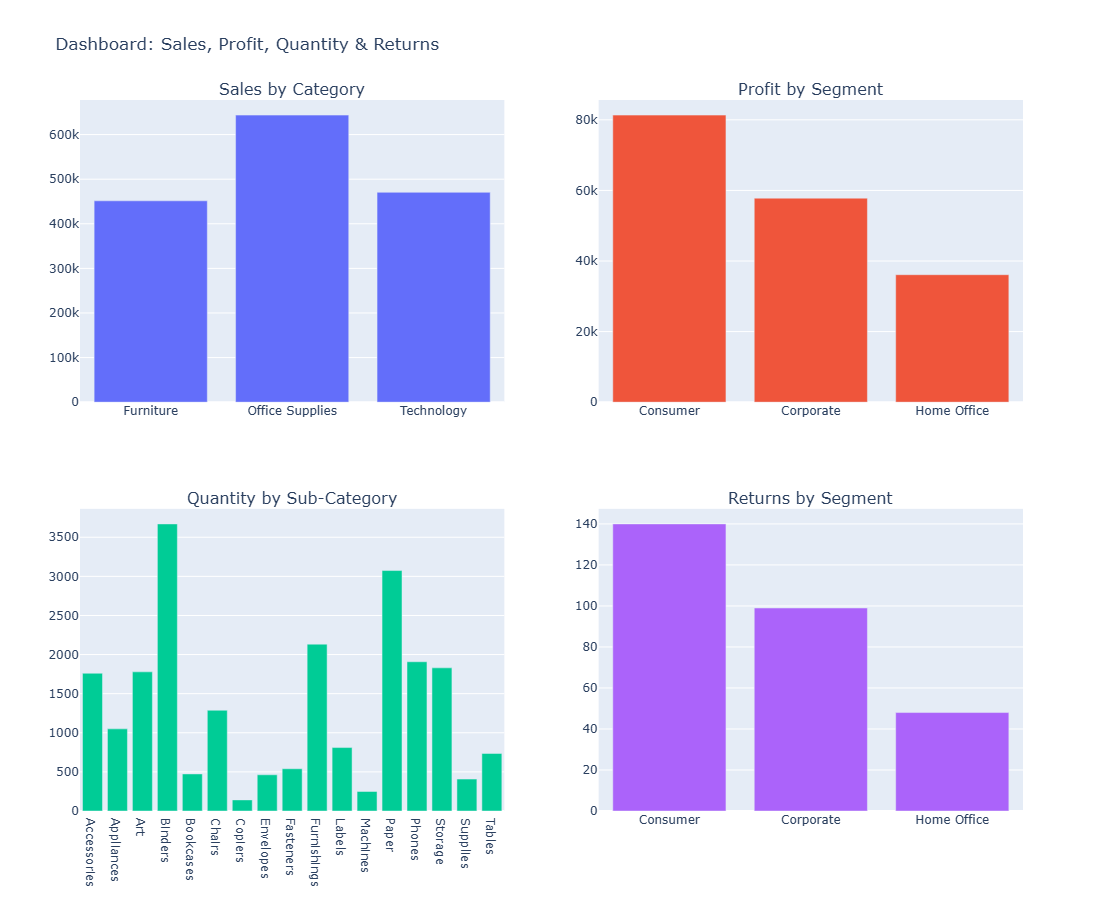

In [7]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create subplots: 2 rows, 2 columns
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Sales by Category", "Profit by Segment","Quantity by Sub-Category", "Returns by Segment"),
    vertical_spacing=0.15,  # space between rows
)
# 1️ Top-left: Sales by Category
sales_cat = df.groupby("Category")["Sales"].sum().reset_index()
fig.add_trace(go.Bar(x=sales_cat['Category'], y=sales_cat['Sales'], name="Sales"),
              row=1, col=1)

# 2️ Top-right: Profit by Segment
profit_seg = df.groupby("Segment")["Profit"].sum().reset_index()
fig.add_trace(go.Bar(x=profit_seg['Segment'], y=profit_seg['Profit'], name="Profit"),
              row=1, col=2)

# 3️ Bottom-left: Quantity by Sub-Category
qty_subcat = df.groupby("Sub-Category")["Quantity"].sum().reset_index()
fig.add_trace(go.Bar(x=qty_subcat['Sub-Category'], y=qty_subcat['Quantity'], name="Quantity"),
              row=2, col=1)

# 4️ Bottom-right: Returns by Segment
returns_seg = df.groupby("Segment")["Returns"].sum().reset_index()
fig.add_trace(go.Bar(x=returns_seg['Segment'], y=returns_seg['Returns'], name="Returns"),row=2, col=2)

fig.update_layout(
    title_text="Dashboard: Sales, Profit, Quantity & Returns",
    height=900,         # Increase overall dashboard height
    showlegend=False
)
fig.show()